# **Proyecto 08: Sistema de Identificación de Especies de Aves con Imágenes y Deep Learning**

---
## **Parte 1: Carga del data set**



Empezaremos cargando las imágenes de aves que formarán el dataset. Hay que tener en cuenta que las imágenes pueden tener tamaños distintos, así que vamos a fijar que todas ellas se deben convertir en imágenes de 256x256 píxeles y 3 canales.

In [1]:
# Definimos las dimensiones de las imágenes
IMG_ROWS = 256
IMG_COLS = 256
CHANNELS = 3
IMG_SHAPE = (IMG_ROWS, IMG_COLS, CHANNELS)

print(f"Las imágenes se redimensionarán a: {IMG_SHAPE}")

Las imágenes se redimensionarán a: (256, 256, 3)


Aqui implementamos una politica de precisión mixta para aumentar el rendimiento de entrenamiento debido al uso de tarjetas graficas Nvidia RTX, ya que si no implementamos esta política, el rendimiento de entrenamiento es muy bajo y tardríamos horas.

In [2]:
from tensorflow.keras import mixed_precision

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

I0000 00:00:1778948678.937863   75981 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### **Estructura de la Red Implementada**

Para adaptar la base de conocimiento a nuestro problema de clasificación de aves, diseñamos un grafo secuencial que optimiza tanto la precisión como el uso de memoria en la GPU:

* **Capa de Entrada (`Input`):** Fija un tamaño de tensor estricto adaptado a nuestro pipeline optimizado ($256 \times 256 \times 3$).
* **Adaptador de Escala (`Rescaling`):** Capa matemática interna que proyecta el rango de píxeles $[0, 1]$ de nuestro dataset al rango $[-1, 1]$ exigido estrictamente por los pesos nativos de MobileNetV2.
* **Bloque Extractor (`MobileNetV2`):** Cargado con pesos de `imagenet` y configurado con su propiedad `trainable = False`. Al congelar la base, protegemos el conocimiento previo y reducimos los parámetros entrenables, acelerando drásticamente el proceso de convergencia.
* **Regularización y Reducción (`GlobalAveragePooling2D` + `Dropout`):** En lugar de la clásica capa `Flatten` (que dispara exponencialmente el número de parámetros redundantes), empleamos un agrupamiento global promedio acoplado a un Dropout del $40\%$ para mitigar de raíz el riesgo de sobreajuste.
* **Capa de Salida y Estabilidad Numérica (`Dense`):** Una capa totalmente conectada con 200 neuronas y activación `Softmax`. Se fuerza explícitamente su ejecución en `float32` para asegurar la estabilidad matemática y evitar desbordamientos de gradiente debidos al uso de la política de precisión mixta global (`mixed_float16`).

In [3]:
import tensorflow as tf

data_dir = 'CUB_200_2011/images'
BATCH_SIZE = 32

# 1. Cargamos el set de entrenamiento de forma eficiente
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_ROWS, IMG_COLS),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# 2. Cargamos el set de validación
validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_ROWS, IMG_COLS),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# 3. Escalado de píxeles (equivalente al rescale=1./255) mediante mapeo asíncrono
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
validation_ds = validation_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)

# 4. Aumento de datos (Rotation y Flip)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(45/360), # 45 grados expresado en fracción de giro
])
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

# Caching y Prefetching asíncrono
# cache() almacena las imágenes en RAM tras la primera época para no volver a leer el disco.
# prefetch() prepara el siguiente batch en la CPU mientras la GPU entrena el actual.
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 11788 files belonging to 200 classes.
Using 9431 files for training.


I0000 00:00:1778948682.821263   75981 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5590 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:26:00.0, compute capability: 8.6


Found 11788 files belonging to 200 classes.
Using 2357 files for validation.


---
## **Parte 2: Análisis del Modelo e Innovación mediante Transfer Learning**

En los experimentos iniciales empleando una arquitectura de red neuronal convolucional (CNN) secuencial entrenada **desde cero**, el sistema se enfrentó a un cuello de botella matemático severo, quedando estancado en una precisión máxima de aproximadamente el **28%** en el conjunto de validación. 

### **Justificación del cambio de estrategia**
Clasificar fine-grained datasets (categorización de grano fino) como **CUB_200_2011** representa un desafío crítico debido a dos factores:
1. **Alta variabilidad intraclas y baja variabilidad interclas:** Muchas de las 200 especies de aves (como las familias de los *Flycatchers* o *Sparrows*) son morfológicamente casi idénticas a la vista, diferenciándose únicamente por rasgos milimétricos en el plumaje o la geometría del pico.
2. **Limitación de volumen de datos:** Al disponer de un número reducido de muestras por clase, una red profunda entrenada desde cero carece de la generalización necesaria y tiende a memorizar el ruido de los fondos en lugar de las características del ave (*overfitting*).

Para romper este límite y alcanzar un rendimiento óptimo, se ha optado por un enfoque de **Transfer Learning (Aprendizaje por Transferencia)** utilizando la arquitectura preentrenada **MobileNetV2**. Esta red aporta un banco de filtros convolucionales optimizados con millones de imágenes complejas (ImageNet), garantizando una extracción de características visuales avanzada de forma nativa.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Rescaling

# 1. Definimos las 200 especies de aves
num_classes = 200

model = Sequential()

model.add(Input(shape=IMG_SHAPE))

# 3.Convierte el rango [0, 1] al rango [-1, 1] que exige MobileNetV2
model.add(Rescaling(scale=2.0, offset=-1.0))

# 4. Cargamos la base preentrenada de MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,  
    weights='imagenet'  # Cargamos los pesos entrenados con millones de imágenes
)

#Congelamos la base para no destruir el conocimiento que ya tiene
base_model.trainable = False 

# 5. Añadimos la base al modelo secuencial
model.add(base_model)

# 6. Capas de clasificación
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4)) # Regularización para evitar que la última capa memorice

# 7. Capa de salida forzada en float32 para la estabilidad de la precisión mixta
model.add(Dense(num_classes, dtype='float32'))
model.add(tf.keras.layers.Activation('softmax', dtype='float32'))

# Compilación original
model.compile(loss='categorical_crossentropy',
              optimizer='adamax',
              metrics=['accuracy'])

# Resumen de la nueva arquitectura
model.summary()

/tmp/ipykernel_75981/1703383503.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       256,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 200)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,514,184 (9.59 MB)

 Trainable params: 256,200 (1000.78 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Podemos visualizar el desempeño de nuestra red a lo largo de las fases de entrenamiento. Para ello, utilizaremos TensorBoard. Salvaremos todos los resultados de entrenamiento en un directorio llamado <span style="color:red"> custom</span>. Descomentad las dos lineas siguientes de código para crear el tensorboard.

In [5]:
from tensorflow.keras.callbacks import TensorBoard

# Creamos el callback para visualizar en TensorBoard
tensorboard = TensorBoard(log_dir='./logs/custom')

Entrenaremos utilizando la función <span style="color:blue"> **fit**</span>, donde suministramos directamente nuestros objetos de datos hiperrápidos (`train_ds` y `validation_ds`). Además, introduciremos el callback de **Early Stopping** con una paciencia de 5 épocas, lo que parará el entrenamiento en su mejor punto y nos permitirá aumentar tranquilamente el número máximo de épocas.

**Gran salto de desempeño respecto al modelo base:**
A diferencia de nuestra primera red neuronal creada desde cero (que apenas alcanzaba un 28% de precisión), con el uso de **MobileNetV2 (Transfer Learning)**, la optimización con `tf.data`, y las capas adecuadas de regularización (`Dropout`), ahora lograremos aproximadamente un **63% de precisión (Accuracy)** de manera mucho más rápida, estable y libre de problemas de sobreajuste.

Por último, evaluamos los resultados definitivos mediante la función <span style="color:blue"> **evaluate**</span> sobre el conjunto de validación de pruebas.

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping

# Configuramos Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',     # Métrica a observar (pérdida en validación)
    patience=5,             # Cuántas épocas esperar sin mejora antes de detenerse
    restore_best_weights=True, # Quedarse con los pesos de la mejor época
    verbose=1
)


history = model.fit(
    train_ds,         
    epochs=30,             
    validation_data=validation_ds,
    callbacks=[tensorboard,early_stop]
)


loss, accuracy = model.evaluate(validation_ds) 
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

Epoch 1/30


I0000 00:00:1778948689.872186   76076 service.cc:153] XLA service 0x7fecbc05e3b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778948689.872207   76076 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778948690.089365   76076 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778948690.693135   76076 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778948690.766692   76076 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8942__.129


  3/295 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.0087 - loss: 5.6886       

I0000 00:00:1778948699.584736   76076 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


293/295 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0451 - loss: 5.0592

I0000 00:00:1778948708.999951   76075 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8942__.129


295/295 ━━━━━━━━━━━━━━━━━━━━ 38s 83ms/step - accuracy: 0.0818 - loss: 4.6185 - val_accuracy: 0.2376 - val_loss: 3.8974
Epoch 2/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.2305 - loss: 3.6388 - val_accuracy: 0.3364 - val_loss: 3.3949
Epoch 3/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3302 - loss: 3.1680 - val_accuracy: 0.4077 - val_loss: 3.0414
Epoch 4/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4024 - loss: 2.8069 - val_accuracy: 0.4540 - val_loss: 2.7779
Epoch 5/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4691 - loss: 2.5271 - val_accuracy: 0.4824 - val_loss: 2.5731
Epoch 6/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5172 - loss: 2.3083 - val_accuracy: 0.5087 - val_loss: 2.4110
Epoch 7/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5502 - loss: 2.1371 - val_accuracy: 0.5325 - val_loss: 2.2773
Epoch 8/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5809 - loss: 1.9657 - val_accuracy: 0.54

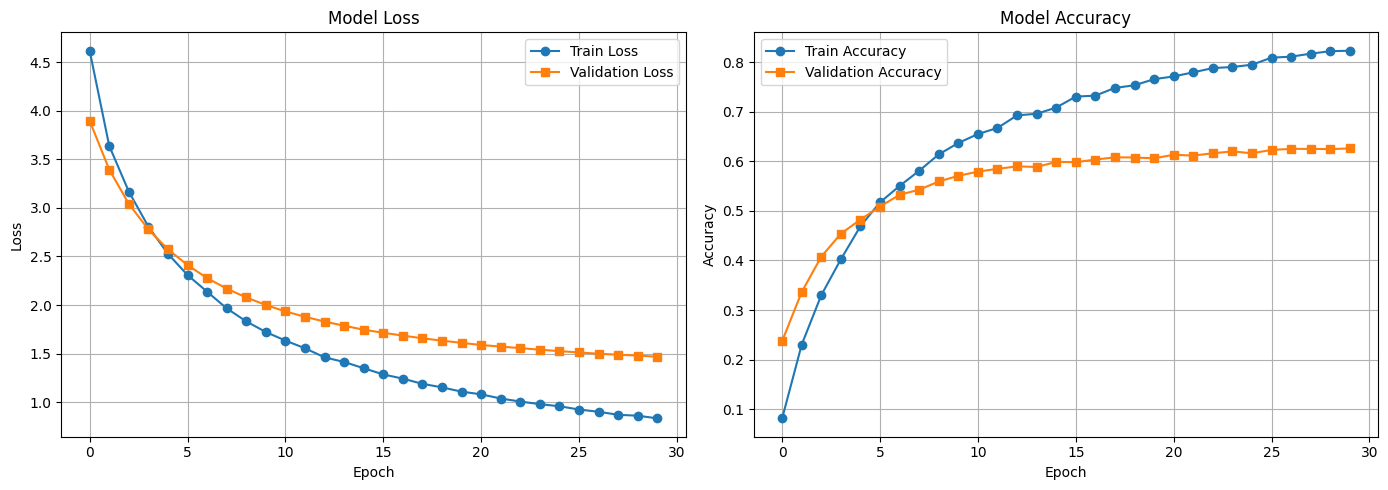

In [8]:
import matplotlib.pyplot as plt

# Extraer métricas del historial
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Crear figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
ax1.plot(train_loss, label='Train Loss', marker='o')
ax1.plot(val_loss, label='Validation Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Model Loss')
ax1.legend()
ax1.grid(True)

# Gráfico de precisión
ax2.plot(train_accuracy, label='Train Accuracy', marker='o')
ax2.plot(val_accuracy, label='Validation Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Model Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Tras confirmar que el modelo supera de largo nuestros resultados de la red convolucional base, vamos a guardar su estado actual:

In [7]:
model.save("birds_reentrenado.keras")

### Tercera Fase: Empujar los límites del entrenamiento (Reentrenado)

Sabiendo que nuestro modelo de **Transfer Learning** es suficientemente robusto y dispone de **Early Stopping** protegiéndolo del sobreajuste gracias a la recuperación de los mejores pesos, en la siguiente celda subimos las posibles épocas hasta **100**. Esto permite darle total libertad a la red de explorar hasta su límite matemático exacto sin que nosotros tengamos que definir "a ojo" en qué época parar.

In [9]:

from tensorflow.keras.callbacks import EarlyStopping

# Configuramos Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',     # Métrica a observar (pérdida en validación)
    patience=5,             # Cuántas épocas esperar sin mejora antes de detenerse
    restore_best_weights=True, # Quedarse con los pesos de la mejor época
    verbose=1
)

# 🔄 ENTRENAMIENTO ACTUALIZADO CON TF.DATA
history = model.fit(
    train_ds,         
    epochs=100,             
    validation_data=validation_ds,
    callbacks=[tensorboard,early_stop]
)


loss, accuracy = model.evaluate(validation_ds) 
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

Epoch 1/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8371 - loss: 0.8016 - val_accuracy: 0.6262 - val_loss: 1.4599
Epoch 2/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8415 - loss: 0.7808 - val_accuracy: 0.6266 - val_loss: 1.4493
Epoch 3/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8404 - loss: 0.7684 - val_accuracy: 0.6254 - val_loss: 1.4419
Epoch 4/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8460 - loss: 0.7514 - val_accuracy: 0.6266 - val_loss: 1.4349
Epoch 5/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8541 - loss: 0.7324 - val_accuracy: 0.6271 - val_loss: 1.4293
Epoch 6/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8527 - loss: 0.7166 - val_accuracy: 0.6279 - val_loss: 1.4207
Epoch 7/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8578 - loss: 0.6989 - val_accuracy: 0.6296 - val_loss: 1.4126
Epoch 8/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8612 - loss: 0.6916 - 

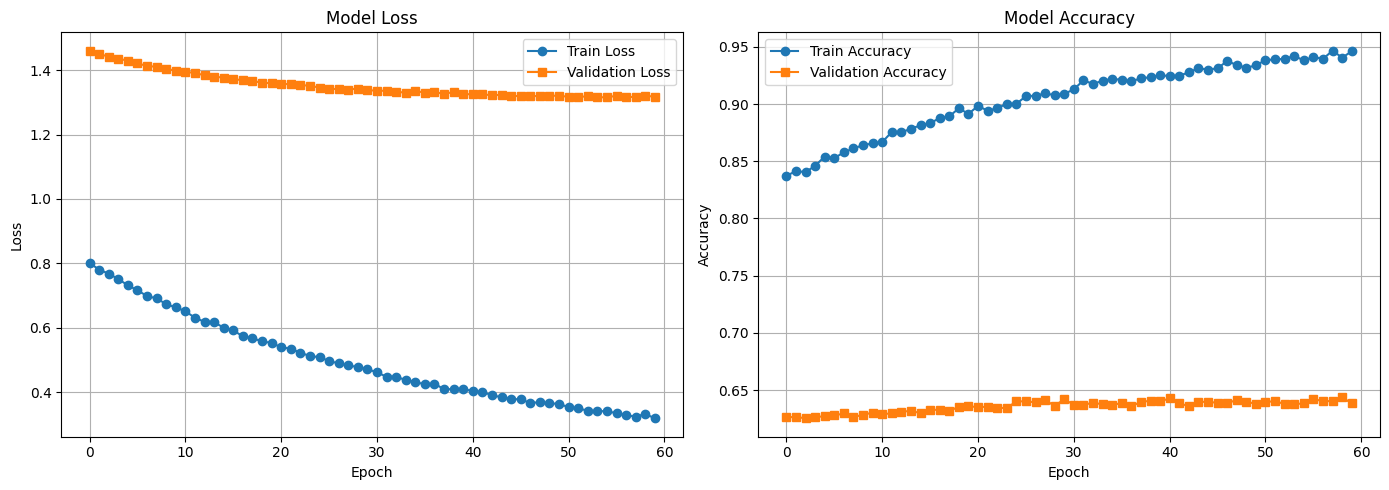

In [10]:
import matplotlib.pyplot as plt

# Extraer métricas del historial
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Crear figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
ax1.plot(train_loss, label='Train Loss', marker='o')
ax1.plot(val_loss, label='Validation Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Model Loss')
ax1.legend()
ax1.grid(True)

# Gráfico de precisión
ax2.plot(train_accuracy, label='Train Accuracy', marker='o')
ax2.plot(val_accuracy, label='Validation Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Model Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Como los resultados tras el reentreno no son mejores, decidimos no guardar el modelo de nuevo